# Notebook 2 — Clustering Analysis
**Project:** E-Commerce CLV Micro-Segmentation

---
**Sections:**
1. Load features
2. Elbow curve — find optimal K
3. K-Means clustering + silhouette score
4. DBSCAN clustering
5. Compare both models
6. Segment profiling

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import sqlite3, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load Features

In [2]:
conn = sqlite3.connect('../data/processed/customers_clean.db')
df = pd.read_sql('SELECT * FROM customers', conn)
conn.close()

CLUSTER_FEATURES = [
    'Days Since Last Purchase_Scaled',
    'Total Spend_Scaled',
    'Items Purchased_Scaled',
    'Purchase_Prob',
    'Engagement_Score',
]
available = [c for c in CLUSTER_FEATURES if c in df.columns]
X = df[available].fillna(0).values
print(f'Feature matrix shape: {X.shape}')
print(f'Features used: {available}')

Feature matrix shape: (350, 5)
Features used: ['Days Since Last Purchase_Scaled', 'Total Spend_Scaled', 'Items Purchased_Scaled', 'Purchase_Prob', 'Engagement_Score']


## 2. Elbow Curve — Find Optimal K

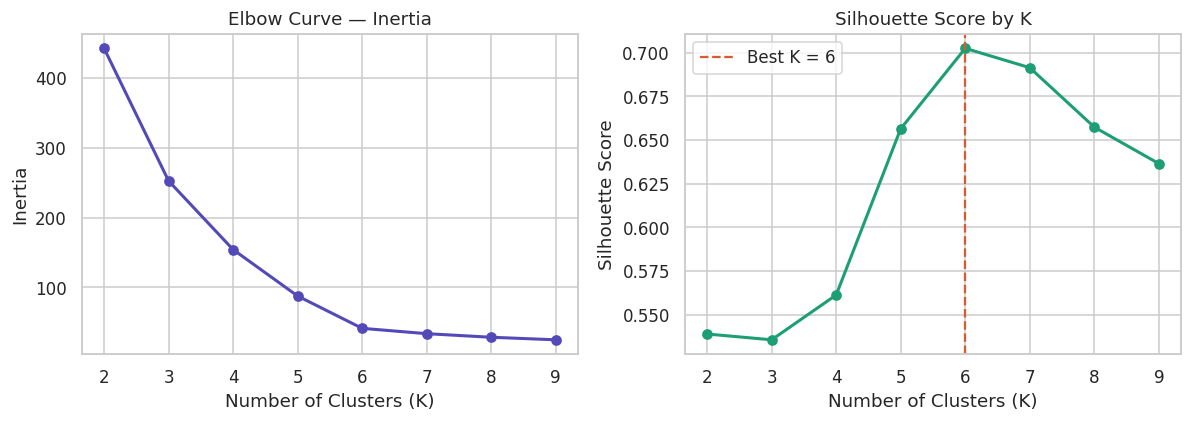

Optimal K = 6 (highest silhouette: 0.7024)
Saved: clustering_elbow.png ✅


In [3]:
k_range = range(2, 10)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(list(k_range), inertias, marker='o', color='#534AB7', linewidth=2)
ax1.set_title('Elbow Curve — Inertia', fontsize=12)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')

best_k = list(k_range)[silhouettes.index(max(silhouettes))]
ax2.plot(list(k_range), silhouettes, marker='o', color='#1D9E75', linewidth=2)
ax2.axvline(best_k, color='#D85A30', linestyle='--', linewidth=1.5, label=f'Best K = {best_k}')
ax2.set_title('Silhouette Score by K', fontsize=12)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()

plt.tight_layout()
plt.savefig('clustering_elbow.png', bbox_inches='tight')
plt.show()
print(f'Optimal K = {best_k} (highest silhouette: {max(silhouettes):.4f})')
print('Saved: clustering_elbow.png ✅')

## 3. K-Means Clustering

In [4]:
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km.fit_predict(X)

km_sil = silhouette_score(X, km_labels)
km_db  = davies_bouldin_score(X, km_labels)

print(f'K-Means Results (K={best_k})')
print(f'  Silhouette Score    : {km_sil:.4f}  (higher = better, max=1)')
print(f'  Davies-Bouldin Index: {km_db:.4f}   (lower = better)')

df['KMeans_Label'] = km_labels

K-Means Results (K=6)
  Silhouette Score    : 0.7024  (higher = better, max=1)
  Davies-Bouldin Index: 0.4274   (lower = better)


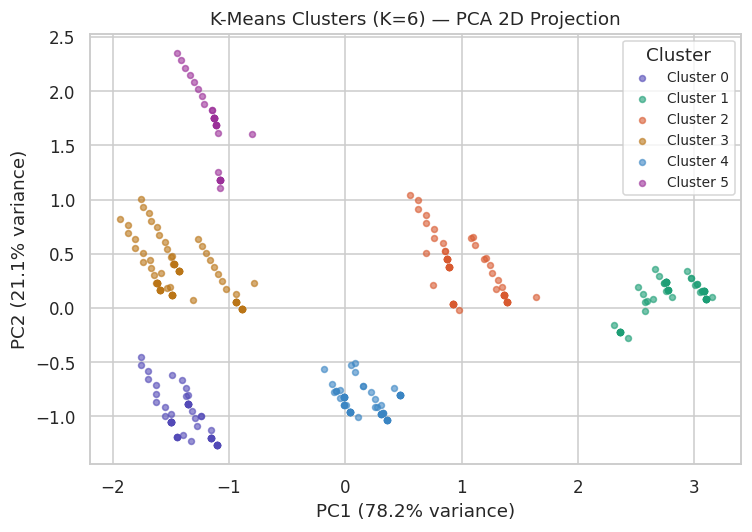

Saved: clustering_kmeans_pca.png ✅


In [5]:
# Visualise with PCA (2D)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 5))
palette = ['#534AB7','#1D9E75','#D85A30','#BA7517','#3A85C3','#9B3099','#CC3A3A']
for k in range(best_k):
    mask = km_labels == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=15, alpha=0.6, label=f'Cluster {k}', color=palette[k % len(palette)])

ax.set_title(f'K-Means Clusters (K={best_k}) — PCA 2D Projection', fontsize=12)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Cluster', loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('clustering_kmeans_pca.png', bbox_inches='tight')
plt.show()
print('Saved: clustering_kmeans_pca.png ✅')

## 4. DBSCAN Clustering

In [6]:
db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(X)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()

print(f'DBSCAN Results')
print(f'  Clusters found : {n_clusters}')
print(f'  Noise points   : {n_noise} ({n_noise/len(db_labels)*100:.1f}%)')

mask = db_labels != -1
if mask.sum() > 1 and n_clusters >= 2:
    db_sil = silhouette_score(X[mask], db_labels[mask])
    db_dbi = davies_bouldin_score(X[mask], db_labels[mask])
    print(f'  Silhouette Score    : {db_sil:.4f}')
    print(f'  Davies-Bouldin Index: {db_dbi:.4f}')
else:
    db_sil = 0
    print('  Not enough clusters for silhouette score')

df['DBSCAN_Label'] = db_labels

DBSCAN Results
  Clusters found : 6
  Noise points   : 0 (0.0%)
  Silhouette Score    : 0.7024
  Davies-Bouldin Index: 0.4274


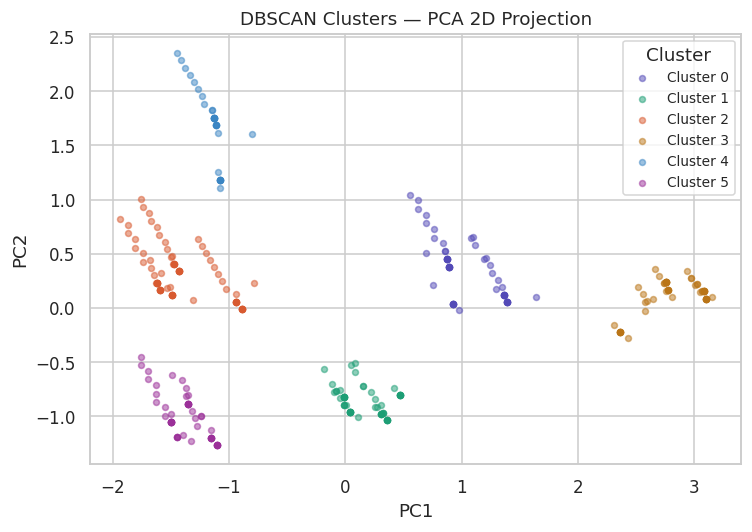

Saved: clustering_dbscan_pca.png ✅


In [7]:
# DBSCAN PCA plot
fig, ax = plt.subplots(figsize=(7, 5))
unique_labels = sorted(set(db_labels))
for k in unique_labels:
    mask = db_labels == k
    label = 'Noise' if k == -1 else f'Cluster {k}'
    color = '#AAAAAA' if k == -1 else palette[k % len(palette)]
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=15, alpha=0.5, label=label, color=color)

ax.set_title('DBSCAN Clusters — PCA 2D Projection', fontsize=12)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(title='Cluster', loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('clustering_dbscan_pca.png', bbox_inches='tight')
plt.show()
print('Saved: clustering_dbscan_pca.png ✅')

## 5. Model Comparison

In [8]:
print('┌─────────────────────────────────────────────┐')
print('│        CLUSTERING MODEL COMPARISON          │')
print('├──────────────┬──────────────┬───────────────┤')
print('│ Metric       │   K-Means    │    DBSCAN     │')
print('├──────────────┼──────────────┼───────────────┤')
print(f'│ Silhouette ↑ │   {km_sil:.4f}   │   {db_sil:.4f}     │')
print(f'│ Clusters     │   {best_k}          │   {n_clusters}           │')
print(f'│ Noise points │   0          │   {n_noise}          │')
print('└──────────────┴──────────────┴───────────────┘')
winner = 'K-Means' if km_sil >= db_sil else 'DBSCAN'
print(f'\n✅ Winner: {winner} (higher silhouette score)')

┌─────────────────────────────────────────────┐
│        CLUSTERING MODEL COMPARISON          │
├──────────────┬──────────────┬───────────────┤
│ Metric       │   K-Means    │    DBSCAN     │
├──────────────┼──────────────┼───────────────┤
│ Silhouette ↑ │   0.7024   │   0.7024     │
│ Clusters     │   6          │   6           │
│ Noise points │   0          │   0          │
└──────────────┴──────────────┴───────────────┘

✅ Winner: K-Means (higher silhouette score)


## 6. Segment Profiling

Segment Profiles (mean | median):
          Total Spend          Items Purchased        Days Since Last Purchase        Average Rating        CLV_Score         
                 mean   median            mean median                     mean median           mean median      mean   median
Segment                                                                                                                       
At-Risk       1165.04  1160.60           15.27   15.0                    24.59   25.0           4.54   4.50    448.62   399.75
Champions      446.89   440.90            7.57    8.0                    22.76   23.0           3.19   3.15      8.79    13.95
Lost           550.13   505.75            9.60   10.0                    38.76   39.0           3.56   3.60     34.47    27.42
Loyalists     1459.77  1470.50           20.00   20.0                    11.17   11.0           4.81   4.80   1256.72  1229.60
Segment 4      805.49   800.90           11.68   12.0                    15.2

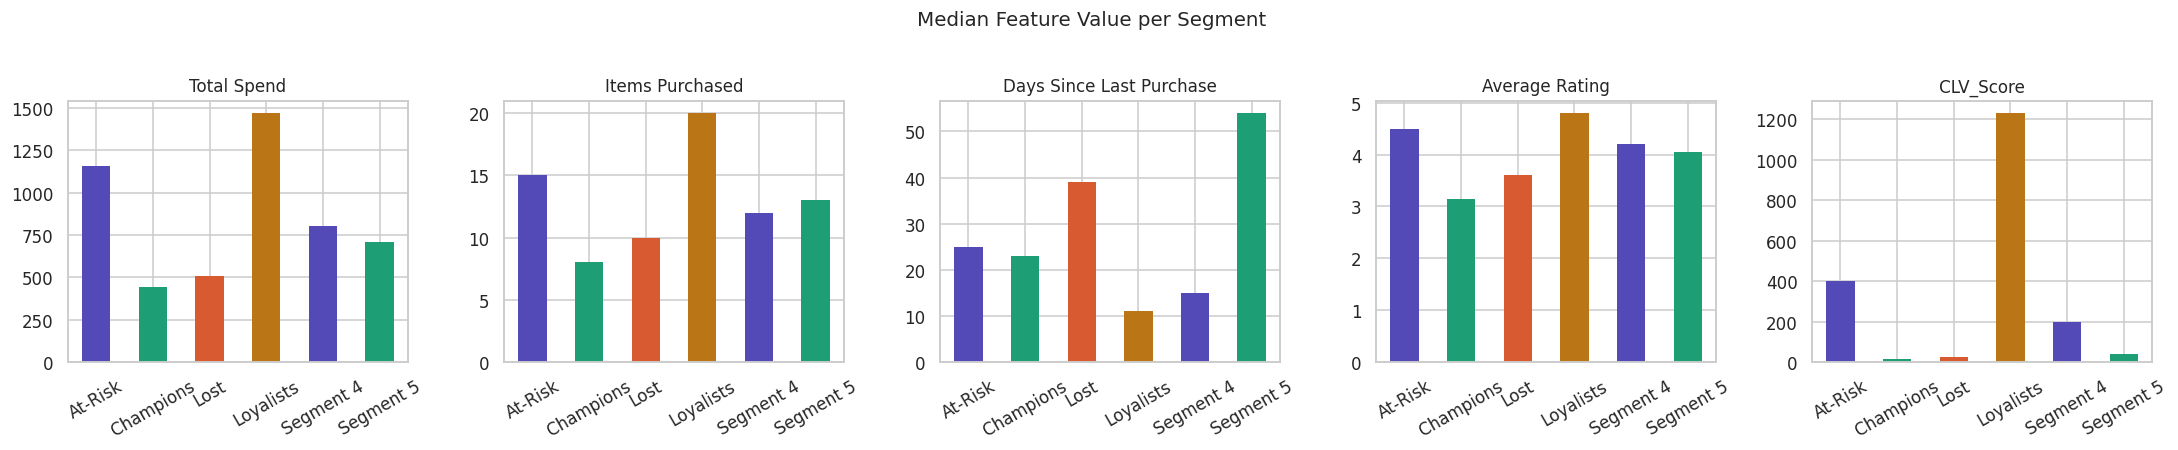

Saved: clustering_segment_profile.png ✅


In [9]:
profile_cols = [c for c in ['Total Spend', 'Items Purchased',
                              'Days Since Last Purchase', 'Average Rating', 'CLV_Score']
                if c in df.columns]

if 'Segment' in df.columns:
    profile = df.groupby('Segment')[profile_cols].agg(['mean','median']).round(2)
    print('Segment Profiles (mean | median):')
    print(profile.to_string())
    
    # Bar charts
    fig, axes = plt.subplots(1, len(profile_cols), figsize=(4 * len(profile_cols), 4))
    colors = ['#534AB7','#1D9E75','#D85A30','#BA7517']
    for ax, col in zip(axes, profile_cols):
        vals = df.groupby('Segment')[col].median()
        vals.plot(kind='bar', ax=ax, color=colors[:len(vals)], edgecolor='none')
        ax.set_title(col, fontsize=11)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)
    fig.suptitle('Median Feature Value per Segment', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('clustering_segment_profile.png', bbox_inches='tight')
    plt.show()
    print('Saved: clustering_segment_profile.png ✅')